# Análisis de Ventas de Videojuegos

Proyecto de análisis exploratorio de datos para identificar patrones de ventas, plataformas líderes, géneros más rentables, perfiles regionales y pruebas de hipótesis relacionadas con calificaciones de usuarios y críticos.

**Autor:** Víctor Iván Reyes Ángeles  
**Rol objetivo:** Data Analyst Junior


In [1]:
# PASO 1, Paso 1. Abre el archivo de datos y estudia la información general 

import pandas as pd # Importo las Librerias
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

from pathlib import Path

# Ruta compatible con ejecución desde la carpeta raíz del repositorio o desde /notebooks
data_path = Path('../data/games.csv')
if not data_path.exists():
    data_path = Path('data/games.csv')

dfgames = pd.read_csv(data_path) # Cargo el archivo CSV y lo convierto a un DataFrame

dfgames # se imprimió para primer contacto visual con el Dataframe y empezar el analisis

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [2]:
dfgames.info() # Se observan datos asentes y columnas como " year of release" tiene formato float, cuando debe de ser  int,
                # "user score" como object cuando debe de ser float y el nombre de las columnas esta en mayúsculas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
# PASO 2, Prepara los datos

dfgames.columns = dfgames.columns.str.lower() # Se convierte a minusculas los encabezados de las columnas, a través de la propiedad
                                                # de columns accedemos a los encabezados, con str a la cadenas de valores y la función
                                                # Lower() se aplica a minúsculas
dfgames # verificamos la conversión de mayúsculas a minúsculas

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [4]:
# Como se mencionó anteriormente, la columna " year of release " esta en un formato distinto y con datos ausentes, procederemos
# a trabajaremos con ellos

dfgames['year_of_release'].isna().sum()/dfgames.shape[0] 

# En esta linea de codigo, revisamos la relacion Datos / Datos Ausentes, es menos del 0.02%, aún así, no nos quedamos quietos, continuamos!

0.01609332934489979

In [5]:
# Vamos a verificar los datos minimos por consola, ya que, mas adelante, los utilizaremos para futuras operaciones
# Utilizamos la función groupby como clave de agrupacion " platform" y siguiente factor " year of release" y a este conjunto
# de valores se le aplica la fúncion min().
yor_min = dfgames.groupby(['platform'])['year_of_release'].min()
yor_min

platform
2600    1980.0
3DO     1994.0
3DS     2011.0
DC      1998.0
DS      1985.0
GB      1988.0
GBA     2000.0
GC      2001.0
GEN     1990.0
GG      1992.0
N64     1996.0
NES     1983.0
NG      1993.0
PC      1985.0
PCFX    1996.0
PS      1994.0
PS2     2000.0
PS3     2006.0
PS4     2013.0
PSP     2004.0
PSV     2011.0
SAT     1994.0
SCD     1993.0
SNES    1990.0
TG16    1995.0
WS      1999.0
Wii     2006.0
WiiU    2012.0
X360    2005.0
XB      2000.0
XOne    2013.0
Name: year_of_release, dtype: float64

In [6]:
# Rellenado de valores ausentes
# A la columna del Data frame " year of release ", se utilizara nuevamente groupby como clave de agrupacion "Platform"
# segundo elemento " year of release" y utlizaremos la herramienta " transform " para aplicar una función a cada elemento
# del Data Frame de la columna " year of release", como lo mencione anteriormente, que se consultaron los valores minimos por consola

dfgames['year_of_release'] = dfgames.groupby(['platform'])['year_of_release'].transform(lambda x: x.fillna(x.min()))

In [7]:
# Ahora, ya que no tenemos datos ausentes, convertimos la columna " year of release " de float a int

dfgames['year_of_release'] = dfgames['year_of_release'].astype(int)

In [8]:
dfgames.info() # Al observar la columna "user score" se observa que es el 48.6 % de datos, rellenar el 51.4 % con algunos otros datos, 
                # afectaria mucho los datos reales, por lo tanto, respetamos la informacion conteniada. A continuacion muestro 2 medios
                # en los cuales, se observa como afectarian los datos al ser remplazados o por ser ausentes se filtran

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.4+ MB


In [9]:
# Al Data frame en la columna " user score", reemplazamos tbd por 0,y poder convertir de object a float

dfgames['user_score'] = dfgames['user_score'].replace('tbd', 0).astype(float)

In [10]:
# calculamos la mediana

dfgames['user_score'].median()

# Al aplicar la mediana, sabemos que, aunque ingresemos datos, dificlmente cambia

6.9

In [11]:

# calculamos la media

dfgames['user_score'].mean()

# aqui al rellenar los valores, ya promedia, se ingreso una cantidad significatica, por lo tanto, obtenemos un cambio radical

5.40034951068504

In [12]:
# Al Data frame en la columna " critic score", reemplazamos los datos ausentes por 0

dfgames['critic_score']=dfgames['critic_score'].fillna(0)

In [13]:
# calculamos la mediana

dfgames['critic_score'].median()

0.0

In [14]:
# calculamos la media

dfgames['critic_score'].mean()

33.574035297636854

In [15]:
# observamos el describe

dfgames['critic_score'].describe()

count    16715.000000
mean        33.574035
std         35.818235
min          0.000000
25%          0.000000
50%          0.000000
75%         70.000000
max         98.000000
Name: critic_score, dtype: float64

In [16]:
# calculando la media y la mediana en las columnas " critic score " y " user score ", no es conveniente llenar los datos ausentes

In [17]:
estimate_critic_score = (dfgames[dfgames['critic_score'].notna()].groupby(['platform', 'name'])['critic_score'].median().reset_index())

In [18]:
estimate_critic_score
# esto estuvo de mas

,platform,name,critic_score
0,2600,Action Force,0.0
1,2600,Adventure,0.0
2,2600,Adventures of Tron,0.0
3,2600,Air Raid,0.0
4,2600,Air-Sea Battle,0.0
...,...,...,...
16704,XOne,XCOM 2,87.0
16705,XOne,ZombiU,0.0
16706,XOne,Zombie Army Trilogy,62.0
16707,XOne,Zoo Tycoon (2013),0.0


In [19]:
# Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores
# en una columna separada

dfgames['total_sales'] = (dfgames['na_sales'] + dfgames['eu_sales'] + dfgames['jp_sales'] + dfgames['other_sales'])

In [20]:
dfgames

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,NaN,NaN,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,0.0,NaN,NaN,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,0.0,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,0.0,NaN,NaN,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,0.0,NaN,NaN,0.01


In [21]:
# PASO 3, Analiza los datos

In [22]:
# Calculamos los juegos lanzados por año

games_per_year = dfgames['year_of_release'].value_counts().sort_index()

games_per_year

# aplicamos la herramienta value_counts sobre la columna del Data frame " year of release "
# y la función sort_index() nos ayudrará a que el año sea el indice y lo organia de menor a mayor

1980      26
1981      46
1982      36
1983      17
1984      14
1985      61
1986      21
1987      16
1988      16
1989      17
1990      16
1991      41
1992      43
1993      62
1994     128
1995     219
1996     266
1997     289
1998     379
1999     338
2000     416
2001     496
2002     829
2003     775
2004     778
2005     969
2006    1065
2007    1197
2008    1427
2009    1426
2010    1255
2011    1145
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: int64

In [23]:
# Calcular ventas totales por plataforma

platform_sales = dfgames.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales

# Aqui se puede observar cuales son las plataformas lideres en venta

# aplicamos un groupby como clave "platform" y total sales como segundo elemento,
# aplicamos la función sum() y sort_values en false para mostrar valores de mayor a menor

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

In [24]:
# Las mejores 5 Plataformas con mas ventas

top_platform_sales = platform_sales.head()

top_platform_sales

# Con la variable anterior, se reutiliza asignando otra nueva variable con la función head y tomar los 5 mejores

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
Name: total_sales, dtype: float64

In [25]:
# Filtrar solo las plataformas top

df_top_platforms = dfgames[dfgames['platform'].isin(top_platform_sales)]

# la herramienta isin se utilizó para filtrar datos y verificar los valores en el Data frame

In [26]:
# Agrupar por plataforma y año

sales_by_year_platform = df_top_platforms.groupby(['year_of_release', 'platform'])['total_sales'].sum()

# para tener un conocimiento del las ventas por año por plataforma, utilizamos un group by como grupo clave
# la plataforma como segundo elemeto, acompañado de las ventas, con la función sum, que es lo que mas nos interesa

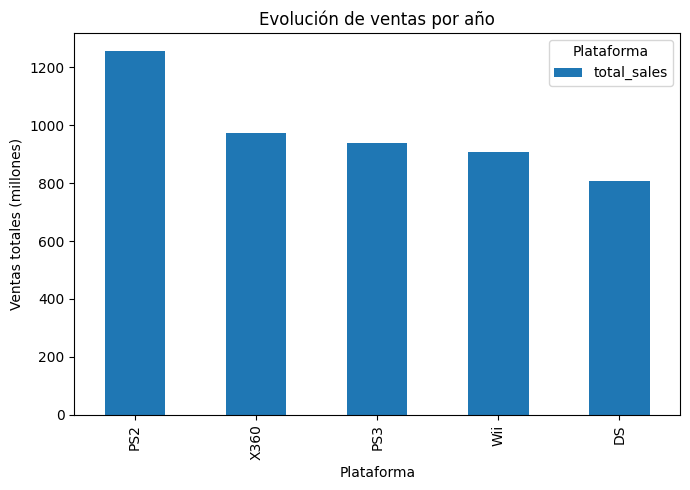

In [27]:
# lo ploteamos 

import matplotlib.pyplot as plt

top_platform_sales.plot(kind='bar', figsize=(7,5))
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones)')
plt.title('Evolución de ventas por año')
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()

In [28]:
# Detectar plataformas populares que ya no tienen ventas

last_sales_year = dfgames.groupby('platform')['year_of_release'].max()
print(last_sales_year.sort_values())

# es un filtrado a la inversa, plataforma desaparecida... 0 ventas

platform
2600    1989
GG      1992
SCD     1994
GEN     1994
NES     1994
3DO     1995
TG16    1995
NG      1996
PCFX    1996
SNES    1999
SAT     1999
WS      2001
GB      2001
N64     2002
PS      2003
GC      2007
GBA     2007
XB      2008
DC      2008
PS2     2011
DS      2013
PSP     2015
PS3     2016
PS4     2016
PSV     2016
3DS     2016
Wii     2016
WiiU    2016
X360    2016
PC      2016
XOne    2016
Name: year_of_release, dtype: int64


In [29]:
# Calcular cuánto tardan las plataformas en aparecer y desaparecer

# al inicio se mencionó, que en el Data frame a la columna " year of release ", se iban a seleccionar los valores del año minimo,
# ya que, existieron plataformas, que solo fueron un año su lanzamiento, por lo tanto, al implicar un codigo, existiese la 
# complejidad para asignar valores, por ello, el valor minimo ya lo podemos asignar y el valor maximo ya es nuestra segunda referencia

platform_lifecycle = dfgames.groupby('platform').agg(first_year=('year_of_release', 'min'), last_year=('year_of_release', 'max'))
platform_lifecycle['duration'] = platform_lifecycle['last_year'] - platform_lifecycle['first_year']

print(platform_lifecycle.sort_values(by='duration', ascending=False))

          first_year  last_year  duration
platform                                 
PC              1985       2016        31
DS              1985       2013        28
GB              1988       2001        13
X360            2005       2016        11
PSP             2004       2015        11
PS2             2000       2011        11
NES             1983       1994        11
DC              1998       2008        10
Wii             2006       2016        10
PS3             2006       2016        10
2600            1980       1989         9
SNES            1990       1999         9
PS              1994       2003         9
XB              2000       2008         8
GBA             2000       2007         7
GC              2001       2007         6
N64             1996       2002         6
3DS             2011       2016         5
PSV             2011       2016         5
SAT             1994       1999         5
WiiU            2012       2016         4
GEN             1990       1994   

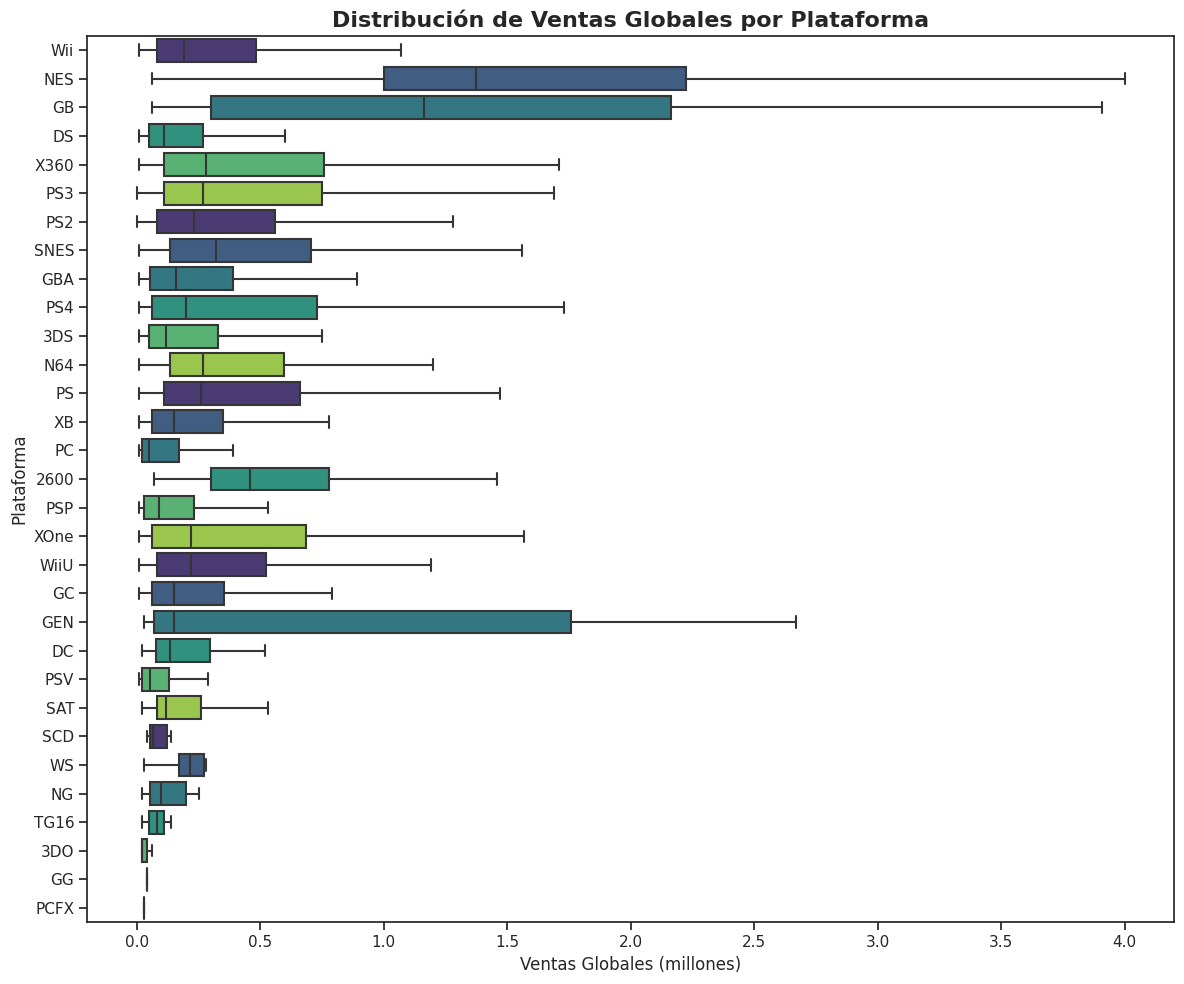

In [30]:
# Diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma

plt.figure(figsize=(12, 10))
sns.set_theme(style="ticks")
palette = sns.color_palette("viridis", as_cmap=False)

sns.boxplot(
    y="platform",
    x="total_sales",
    data=dfgames,
    palette=palette,
    showfliers=False
)

plt.title("Distribución de Ventas Globales por Plataforma", fontsize=16, weight='bold')
plt.xlabel("Ventas Globales (millones)")
plt.ylabel("Plataforma")
plt.tight_layout()
plt.show()

#podemos observar que las plataformas " NES ", " GB " Y " GEN ", sus ventas en millones globales, fueron un exito, independiente de su año de lanzamiento

Correlación Críticos vs Ventas: 0.20
Correlación Usuarios vs Ventas: 0.17


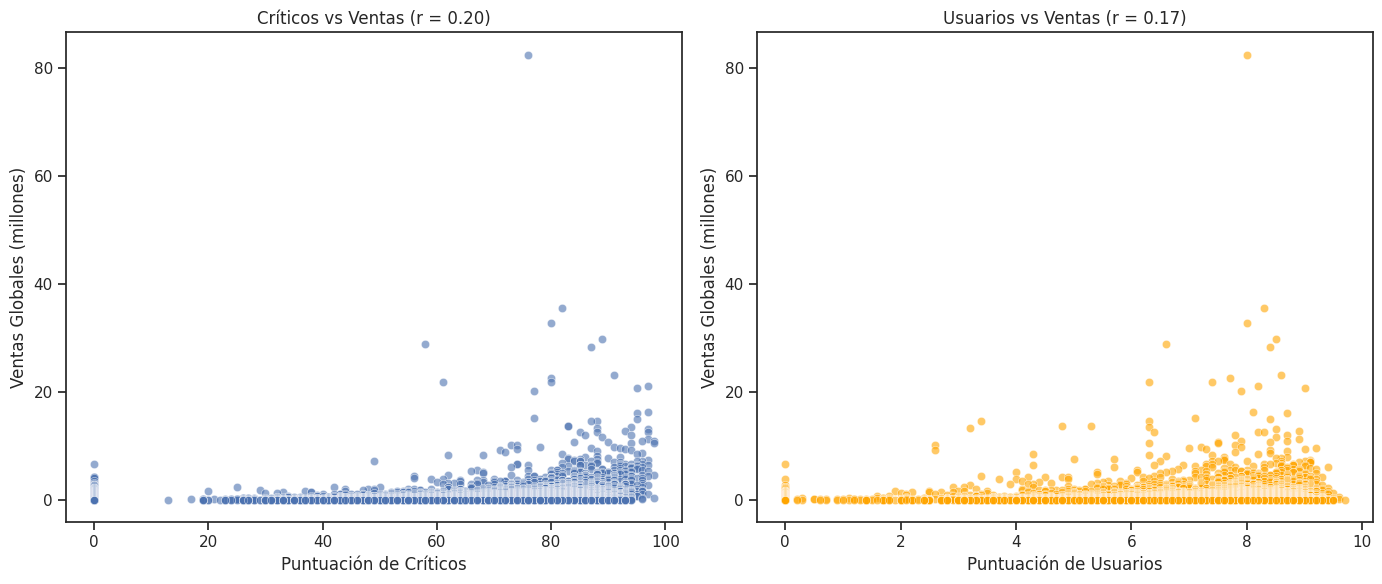

In [31]:
# Filtrar filas sin NaN en columnas relevantes

df_clean = dfgames.dropna(subset=['critic_score', 'user_score', 'total_sales'])

# Calcular correlaciones
corr_critic = df_clean['critic_score'].corr(df_clean['total_sales'])
corr_user = df_clean['user_score'].corr(df_clean['total_sales'])

print(f"Correlación Críticos vs Ventas: {corr_critic:.2f}")
print(f"Correlación Usuarios vs Ventas: {corr_user:.2f}")

# Crear subplots
plt.figure(figsize=(14,6))

# Dispersión Critic Score
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='critic_score',
    y='total_sales',
    data=df_clean,
    alpha=0.6
)
plt.title(f'Críticos vs Ventas (r = {corr_critic:.2f})')
plt.xlabel('Puntuación de Críticos')
plt.ylabel('Ventas Globales (millones)')

# Dispersión User Score
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='user_score',
    y='total_sales',
    data=df_clean,
    alpha=0.6,
    color='orange'
)
plt.title(f'Usuarios vs Ventas (r = {corr_user:.2f})')
plt.xlabel('Puntuación de Usuarios')
plt.ylabel('Ventas Globales (millones)')

plt.tight_layout()
plt.show()

# vaya! mejor calificacion, mejores ventas... es lo que se espera

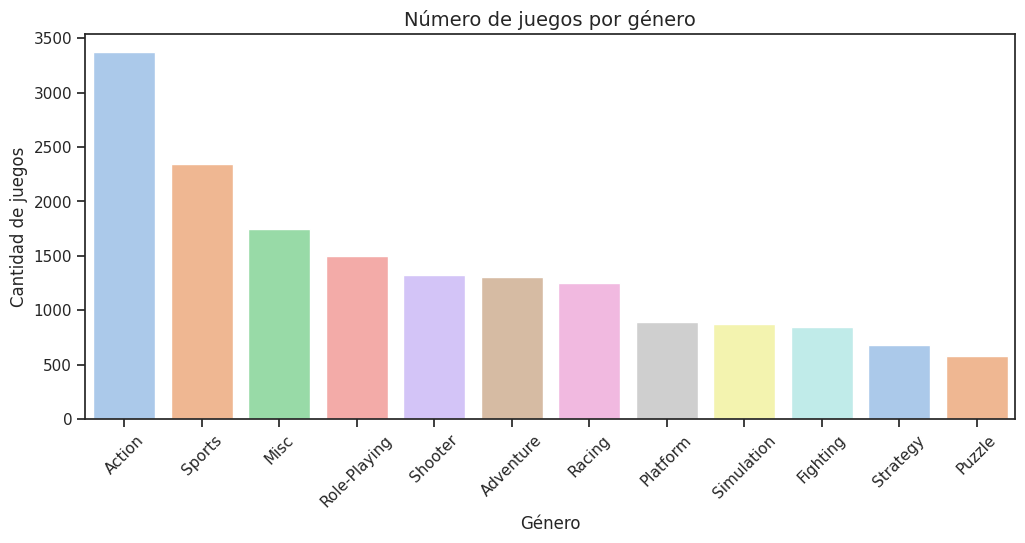

In [32]:
# Echa un vistazo a la distribución general de los juegos por género.
# ¿Qué se puede decir de los géneros más rentables?, los juegos de accion y deportes, rompecabezas y estrategia es lo menos popular
# ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?, de igual modo, a mayores ventas, mayor produccion de categoria " NEGOCIOS "

# --- 1. Distribución de juegos por género ---
plt.figure(figsize=(12,5))
sns.countplot(data=dfgames, x='genre', order=dfgames['genre'].value_counts().index, palette='pastel')
plt.title('Número de juegos por género', fontsize=14)
plt.xlabel('Género')
plt.ylabel('Cantidad de juegos')
plt.xticks(rotation=45)
plt.show()

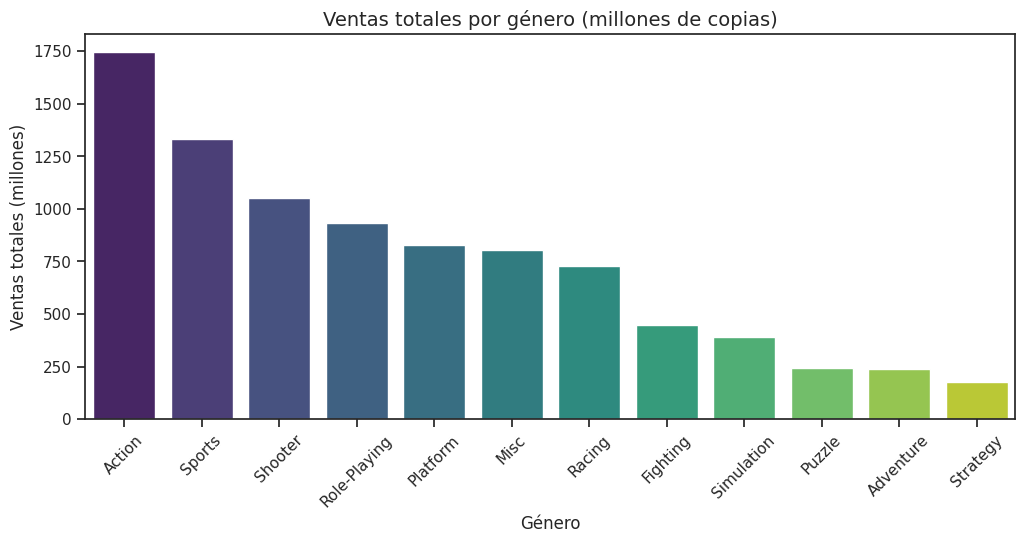

In [33]:
# --- 2. Ventas totales por género ---
genre_sales = dfgames.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis')
plt.title('Ventas totales por género (millones de copias)', fontsize=14)
plt.xlabel('Género')
plt.ylabel('Ventas totales (millones)')
plt.xticks(rotation=45)
plt.show()

In [34]:
# PASO 4, Crea un perfil de usuario para cada región

In [35]:
# Ventas totales por plataforma y región
platform_sales_reg = dfgames.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales']].sum()

# Calcular cuota de mercado en %
region_totals = platform_sales_reg.sum()
market_share = platform_sales_reg.div(region_totals) * 100

# Top 5 plataformas por región
top5_na = market_share['na_sales'].sort_values(ascending=False).head(5)
top5_eu = market_share['eu_sales'].sort_values(ascending=False).head(5)
top5_jp = market_share['jp_sales'].sort_values(ascending=False).head(5)

print("Top 5 NA:\n", top5_na, "\n")
print("Top 5 EU:\n", top5_eu, "\n")
print("Top 5 JP:\n", top5_jp, "\n")

Top 5 NA:
 platform
X360    13.685191
PS2     13.262008
Wii     11.287153
PS3      8.938181
DS       8.686270
Name: na_sales, dtype: float64 

Top 5 EU:
 platform
PS2     13.993244
PS3     13.622060
X360    11.166880
Wii     10.814255
PS       8.809859
Name: eu_sales, dtype: float64 

Top 5 JP:
 platform
DS      13.532762
PS      10.777188
PS2     10.729399
SNES     8.983559
3DS      7.759544
Name: jp_sales, dtype: float64 



In [36]:
# Ejemplo con este dataset

#(los números pueden variar un poco según el filtrado)

# Norteamérica (NA)

# Dominio de consolas de Nintendo y Microsoft: X360, Wii, PS2, PS3, DS.

# Xbox 360 suele ser muy fuerte aquí (alto porcentaje), pero no tanto en Japón.

# Europa (EU)

# Más equilibrado: PS2, PS3, Wii, X360, PSP.

# PlayStation suele dominar más en Europa que en NA.

# Japón (JP)

# Claramente orientado a Nintendo y portátiles: DS, 3DS, PSP, PS, Wii.

# Observaciones sobre variaciones

# Xbox 360 → muy fuerte en NA, buena en EU, casi irrelevante en JP.

# PlayStation 2/3, dominan en EU, muy presentes en NA, moderados en JP.

# Nintendo DS/3DS, enormes en JP, fuertes en NA, menos dominantes en EU.

# Wii, ventas fuertes en las tres regiones, pero especialmente en NA.

# PSP, más éxito en JP que en NA.

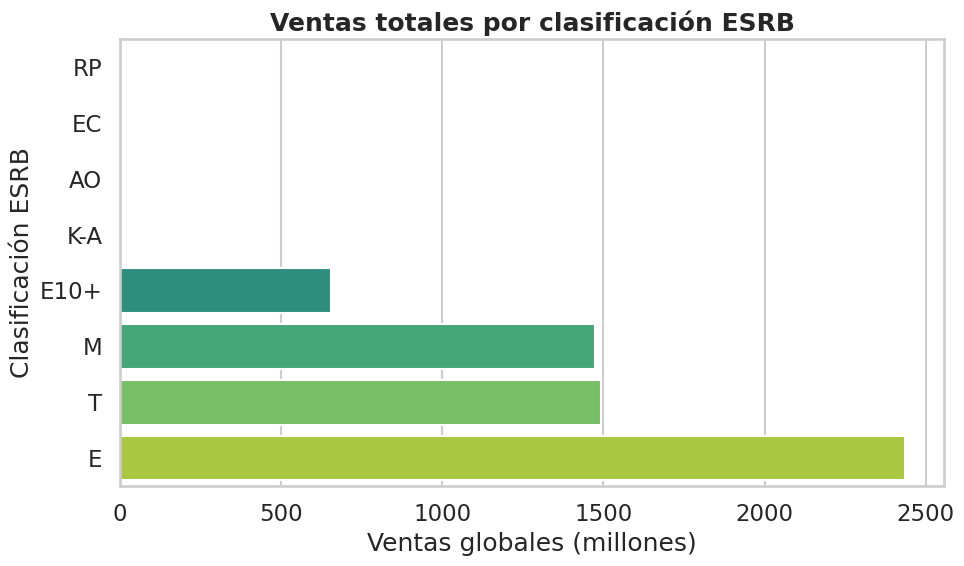

In [37]:
# Estilo general

sns.set_theme(style="whitegrid", context="talk")

# Ventas totales por rating
rating_sales = dfgames.groupby('rating')['total_sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(
    x=rating_sales.values,
    y=rating_sales.index,
    palette="viridis"
)

plt.title('Ventas totales por clasificación ESRB', fontsize=18, weight='bold')
plt.xlabel('Ventas globales (millones)')
plt.ylabel('Clasificación ESRB')
plt.tight_layout()
plt.show()

# las clasificaciones entre los 10 y 17 años son las mas vendidas, las clasificacion para menores y adultos no son relevantes

In [39]:
# Prueba las hipótesis

xone_scores = dfgames.loc[dfgames['platform'] == 'XOne', 'user_score'].dropna()
pc_scores = dfgames.loc[dfgames['platform'] == 'PC', 'user_score'].dropna()

st.levene(xone_scores, pc_scores)

# Primero, lo que quería era comparar si las calificaciones promedio de los usuarios en Xbox One y PC eran iguales o diferentes.
# Pero antes de comparar promedios, tenía que revisar si la variación (la dispersión de las calificaciones) era parecida en ambas
# plataformas, porque eso influye en qué tipo de prueba estadística usar.

#Por eso, planteé así las hipótesis para la prueba de Levene:

# H0: Las varianzas son iguales en ambas plataformas.
# H1: Las varianzas son diferentes.

# Si el resultado me daba un p-valor mayor a 0.05, asumía que las varianzas eran iguales. Si era menor, asumía que eran distintas.

# Después, según ese resultado, pasaba a la prueba t para comparar medias:

# H0: El promedio de calificaciones en Xbox One y PC es el mismo.
# H1: El promedio de calificaciones es diferente entre las dos plataformas.

# La idea fue hacerlo en dos pasos para elegir bien la prueba y que la comparación de promedios fuera confiable

# Apliqué los mismos criterios en la segunda hipotesis

# Apliqué un nivel 10% de tolerancia en el alpha

LeveneResult(statistic=1.1694924732558933, pvalue=0.2797636855427242)

In [41]:
# Filtrar datos y eliminar NaN


xone_scores = dfgames.loc[dfgames['platform'] == 'XOne', 'user_score'].dropna()
pc_scores = dfgames.loc[dfgames['platform'] == 'PC', 'user_score'].dropna()


xone_scores
pc_scores
alpha = 0.10

results = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print('valor p:', results.pvalue)

if results.pvalue < alpha:
    print("Rechazamosla hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 0.0032623626978264667
Rechazamosla hipótesis nula


In [40]:
action_scores = dfgames.loc[dfgames['genre'] == 'Action', 'critic_score'].dropna()
sports_scores = dfgames.loc[dfgames['genre'] == 'Sports', 'critic_score'].dropna()

st.levene(action_scores, sports_scores)

LeveneResult(statistic=90.00261773048669, pvalue=3.403814103728162e-21)

In [42]:

action_scores = dfgames.loc[dfgames['genre'] == 'Action', 'critic_score'].dropna()
sports_scores = dfgames.loc[dfgames['genre'] == 'Sports', 'critic_score'].dropna()


action_scores
sports_scores
alpha = 0.10

results = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print('valor p:', results.pvalue)

if results.pvalue < alpha:
    print("Rechazamosla hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 0.4229807447766385
No podemos rechazar la hipótesis nula


In [ ]:
# PASO 6, Conclusiones generales

## Conclusiones generales

En este proyecto se cargó y exploró el dataset de videojuegos, se normalizaron nombres de columnas, se ajustaron tipos de datos y se revisaron valores ausentes. Posteriormente se calcularon ventas totales por juego, plataforma, género y región.

El análisis permitió identificar plataformas líderes, observar ciclos de vida de consolas, comparar ventas globales y regionales, evaluar la relación entre calificaciones y ventas, y aplicar pruebas estadísticas para contrastar hipótesis.

Este proyecto integra habilidades de limpieza de datos, análisis exploratorio, visualización, agregaciones con `groupby`, análisis de correlación y pruebas de hipótesis, con enfoque en toma de decisiones basada en datos.
